# Análisis de errores por slices y Plan de mitigación

El **plan de mitigación de errores** tiene dos fases:

- **Diagnóstico**: análisis de errores por **slices** (subpoblaciones) sobre las predicciones OOF del campeón del Sprint 3, con un embudo estadístico de 3 etapas para confirmar subpoblaciones débiles.
- **Fase A — estrategias candidatas**: se evalúan de forma independiente tres estrategias de mitigación (A1 stacking, A2 re-inclusión de features, A3 umbral por slice), cada una contra el mismo baseline y con el mismo criterio de aceptación estadística.
- **Fase B — combinación forward incremental**: las estrategias aceptadas se combinan de forma incremental, verificando que cada adición aporte mejora significativa.
- **Evaluación final**: el modelo resultante se aplica **una sola vez** al hold-out.

## Configuración

In [1]:
import warnings, os, json, time, joblib
from datetime import datetime
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             accuracy_score, roc_auc_score, average_precision_score,
                             brier_score_loss, confusion_matrix, precision_recall_curve,
                             roc_curve)
from sklearn.cluster import DBSCAN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

import xgboost as xgb
from catboost import CatBoostClassifier
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)
CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150,
                     'font.size': 11, 'axes.titlesize': 13})

def coral(txt):
    return f'\033[38;2;255;127;80m{txt}\033[0m'

# ── Directorios de salida ──
OUT = 'outputs_sprint4'
DIR_DATA = f'{OUT}/data'
DIR_MOD  = f'{OUT}/models'
DIR_FIG  = f'{OUT}/figures'
DIR_TAB  = f'{OUT}/tables'
for d in [DIR_DATA, DIR_MOD, DIR_FIG, DIR_TAB]:
    os.makedirs(d, exist_ok=True)

# Versiones
versiones = {}
import sklearn, imblearn, catboost, scipy
for lib in [np, pd, sklearn, imblearn, xgb, lgb, catboost, scipy, joblib]:
    versiones[lib.__name__.split('.')[0]] = lib.__version__
versiones['python'] = __import__('platform').python_version()
versiones['matplotlib'] = __import__('matplotlib').__version__
versiones['seaborn'] = sns.__version__
print('Versiones:', json.dumps(versiones, indent=2))

Versiones: {
  "numpy": "2.4.6",
  "pandas": "2.3.3",
  "sklearn": "1.9.0",
  "imblearn": "0.14.2",
  "xgboost": "3.3.0",
  "lightgbm": "4.6.0",
  "catboost": "1.2.10",
  "scipy": "1.18.0",
  "joblib": "1.5.3",
  "python": "3.12.1",
  "matplotlib": "3.11.0",
  "seaborn": "0.13.2"
}


## Carga de artefactos del Sprint 3

Se cargan los productos del Sprint 3: probabilidades OOF de los tres modelos, modelos calibrados, features seleccionadas por modelo y configuración del campeón. También se reconstruyen los sets de features (usando los modelos de clustering ajustados en el Sprint 2) para poder predecir sobre el hold-out.

In [2]:
# ── Resúmenes previos ──
RESUMEN_S0 = json.load(open('outputs_sprint0/resumen_sprint0.json'))
RESUMEN_S1 = json.load(open('outputs_sprint1/resumen_sprint1.json'))
RESUMEN_S2 = json.load(open('outputs_sprint2/resumen_sprint2.json'))
RESUMEN_S3 = json.load(open('outputs_sprint3/resumen_sprint3.json'))

# ── Configuración del top-3 y campeón ──
TOP3_CONFIG = json.load(open('outputs_sprint2/data/top3_config.json'))
TOP_3 = list(TOP3_CONFIG.keys())
FEATURES_S3 = json.load(open('outputs_sprint3/data/features_s3_por_modelo.json'))
CONFIG_CAMPEON = json.load(open('outputs_sprint3/data/config_campeon_s3.json'))
CAMPEON_S3 = CONFIG_CAMPEON['modelo']
UMBRAL_S3 = CONFIG_CAMPEON['umbral']
PARAMS_CAMPEON = CONFIG_CAMPEON['params_s3']
CAL_CAMPEON = CONFIG_CAMPEON['calibracion']
F1_SPRINT3 = RESUMEN_S3['f1_cv_final']

# ── OOF del top-3 (probabilidades calibradas) ──
oof_raw = json.load(open('outputs_sprint3/data/oof_probas_top3.json'))
OOF_MATRIX = pd.DataFrame({m: oof_raw[m] for m in TOP_3})

# ── Modelos calibrados ──
modelos_cal = {}
for m in TOP_3:
    slug = m.lower().replace(' ', '_')
    modelos_cal[m] = joblib.load(f'outputs_sprint3/models/modelo_calibrado_{slug}.pkl')

# ── Datos ──
df = pd.read_csv('../data/processed/data_procesada.csv')
EXCLUIR = ['Au_ppm', 'target_Au', 'East', 'North', 'Level']
FEATURES_BASE = sorted([c for c in df.columns if c not in EXCLUIR])

idx_train = np.load('outputs_sprint0/data/idx_train.npy')
idx_test  = np.load('outputs_sprint0/data/idx_test.npy')
X_train = df.loc[idx_train, FEATURES_BASE].reset_index(drop=True)
X_test  = df.loc[idx_test,  FEATURES_BASE].reset_index(drop=True)
y_train = df.loc[idx_train, 'target_Au'].reset_index(drop=True)
y_test  = df.loc[idx_test,  'target_Au'].reset_index(drop=True)

# Coordenadas, elevación y Au_ppm (para slices, no como features)
coords_train = df.loc[idx_train, ['East', 'North']].reset_index(drop=True)
coords_test  = df.loc[idx_test,  ['East', 'North']].reset_index(drop=True)
level_train = df.loc[idx_train, 'Level'].reset_index(drop=True)
level_test  = df.loc[idx_test,  'Level'].reset_index(drop=True)
au_train = df.loc[idx_train, 'Au_ppm'].reset_index(drop=True)
au_test  = df.loc[idx_test,  'Au_ppm'].reset_index(drop=True)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Prevalencia train: {y_train.mean():.3f}, test: {y_test.mean():.3f}')
print(f'Campeón S3: {CAMPEON_S3} (F1_CV = {F1_SPRINT3:.4f}, umbral = {UMBRAL_S3:.4f})')
print(f'Top-3: {TOP_3}')
print(f'OOF matrix: {OOF_MATRIX.shape}')

Train: (1705, 46), Test: (427, 46)
Prevalencia train: 0.122, test: 0.122
Campeón S3: XGBoost (F1_CV = 0.7598, umbral = 0.4214)
Top-3: ['CatBoost', 'XGBoost', 'HistGradientBoosting']
OOF matrix: (1705, 3)


In [3]:
# ── Reconstruir sets de features + features de cluster (modelos de S2) ──
modelos_cl_raw = joblib.load('outputs_sprint2/models/clustering_raw.pkl')
NO_ECON = RESUMEN_S2['elementos_no_economicos']

def generar_cluster_features(Xtr_esp, Xte_esp, modelos_cl, etiqueta):
    sc  = modelos_cl['scaler']
    km  = modelos_cl['kmeans']
    gm  = modelos_cl['gmm']
    eps = modelos_cl['eps']
    Ztr = sc.transform(Xtr_esp); Zte = sc.transform(Xte_esp)
    def dist_centroides(Z):
        return np.min(np.linalg.norm(Z[:, None, :] - km.cluster_centers_[None, :, :], axis=2), axis=1)
    db_tr = DBSCAN(eps=eps, min_samples=10).fit_predict(Ztr)
    db_te = DBSCAN(eps=eps, min_samples=10).fit_predict(Zte)
    ftr = pd.DataFrame({
        f'kmeans_label_{etiqueta}': km.predict(Ztr), f'kmeans_dist_{etiqueta}': dist_centroides(Ztr),
        f'gmm_label_{etiqueta}': gm.predict(Ztr), f'gmm_prob_max_{etiqueta}': gm.predict_proba(Ztr).max(axis=1),
        f'dbscan_outlier_{etiqueta}': (db_tr == -1).astype(int),
    }, index=Xtr_esp.index)
    fte = pd.DataFrame({
        f'kmeans_label_{etiqueta}': km.predict(Zte), f'kmeans_dist_{etiqueta}': dist_centroides(Zte),
        f'gmm_label_{etiqueta}': gm.predict(Zte), f'gmm_prob_max_{etiqueta}': gm.predict_proba(Zte).max(axis=1),
        f'dbscan_outlier_{etiqueta}': (db_te == -1).astype(int),
    }, index=Xte_esp.index)
    return ftr, fte

# Cluster features RAW (se usan tanto para el set E2 como para el slice de cluster)
cl_tr, cl_te = generar_cluster_features(X_train[NO_ECON], X_test[NO_ECON], modelos_cl_raw, 'raw')

SETS_TR, SETS_TE = {}, {}
SETS_TR['E0 Base'] = X_train.copy()
SETS_TE['E0 Base'] = X_test.copy()
SETS_TR['E2 +Cluster RAW'] = pd.concat([X_train, cl_tr], axis=1)
SETS_TE['E2 +Cluster RAW'] = pd.concat([X_test, cl_te], axis=1)

for m in TOP_3:
    s = TOP3_CONFIG[m]['set']
    feats = FEATURES_S3[m]
    print(f'{m}: set={s}, {len(feats)} features S3 — '
          f'disponibles: {all(f in SETS_TR[s].columns for f in feats)}')

CatBoost: set=E0 Base, 29 features S3 — disponibles: True
XGBoost: set=E0 Base, 32 features S3 — disponibles: True
HistGradientBoosting: set=E2 +Cluster RAW, 25 features S3 — disponibles: True


## Funciones auxiliares

In [4]:
def crear_clf(mod, params):
    if mod == 'CatBoost':
        return CatBoostClassifier(**params, random_seed=SEED, verbose=0, allow_writing_files=False)
    if mod == 'XGBoost':
        return xgb.XGBClassifier(**params, random_state=SEED, eval_metric='logloss',
                                 tree_method='hist', n_jobs=-1)
    if mod == 'HistGradientBoosting':
        from sklearn.ensemble import HistGradientBoostingClassifier
        return HistGradientBoostingClassifier(**params, random_state=SEED)
    if mod == 'LightGBM':
        return lgb.LGBMClassifier(**params, random_state=SEED, verbose=-1, n_jobs=-1)
    raise ValueError(f'Modelo no soportado: {mod}')

def make_pipe(mod, params, balanceo='RandomOverSampler'):
    if balanceo == 'RandomOverSampler':
        bal = RandomOverSampler(random_state=SEED)
    else:
        raise ValueError(f'Balanceo no soportado: {balanceo}')
    return ImbPipeline([
        ('sc', StandardScaler()),
        ('bal', bal),
        ('clf', crear_clf(mod, params)),
    ])

def oof_proba(factory, X, yv):
    """Probabilidades OOF: entrena en cada fold de train, predice el fold de validación."""
    oof = np.zeros(len(yv), dtype=float)
    for tr_idx, va_idx in CV5.split(X, yv):
        est = factory()
        est.fit(X.iloc[tr_idx], yv.iloc[tr_idx])
        oof[va_idx] = est.predict_proba(X.iloc[va_idx])[:, 1]
    return oof

def umbral_optimo(y_true, p):
    """Umbral que maximiza F1 sobre las probabilidades dadas."""
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1c = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0)
    i = int(np.argmax(f1c))
    return float(thr[i]) if i < len(thr) else 0.5

def bootstrap_f1(y_true, y_pred, n_boot=2000, ci=0.95):
    """Bootstrap del F1 clase positiva; devuelve (f1_medio, lo, hi)."""
    rng = np.random.RandomState(SEED)
    n = len(y_true)
    scores = np.empty(n_boot)
    yt = np.asarray(y_true); yp = np.asarray(y_pred)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        scores[b] = f1_score(yt[idx], yp[idx], zero_division=0)
    alpha = (1 - ci) / 2
    return float(np.mean(scores)), float(np.percentile(scores, 100*alpha)), float(np.percentile(scores, 100*(1-alpha)))

def bootstrap_delta(y_true, y_pred_base, y_pred_new, n_boot=2000):
    """Bootstrap pareado de ΔF1 (nuevo − base). Devuelve (delta_medio, lo, hi, p_boot).
    p_boot = proporción de réplicas con Δ ≤ 0 (test unilateral de mejora)."""
    rng = np.random.RandomState(SEED)
    n = len(y_true)
    yt = np.asarray(y_true)
    pb = np.asarray(y_pred_base); pn = np.asarray(y_pred_new)
    deltas = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        deltas[b] = (f1_score(yt[idx], pn[idx], zero_division=0) -
                     f1_score(yt[idx], pb[idx], zero_division=0))
    return (float(np.mean(deltas)), float(np.percentile(deltas, 2.5)),
            float(np.percentile(deltas, 97.5)), float((deltas <= 0).mean()))

print('Helpers: crear_clf, make_pipe, oof_proba, umbral_optimo, bootstrap_f1, bootstrap_delta')

Helpers: crear_clf, make_pipe, oof_proba, umbral_optimo, bootstrap_f1, bootstrap_delta


## Analisis de errores por slices

El **baseline** del Sprint 4 es el campeón del Sprint 3 con sus probabilidades OOF calibradas y su umbral de decisión. Sobre sus predicciones OOF se construyen **slices** (subpoblaciones) para diagnosticar dónde el modelo comete más errores. Todos los bordes/umbrales de los slices se calculan **exclusivamente en train**, de modo que puedan reproducirse en el hold-out sin fuga de información.

**Slices definidos:**
1. **Banda de probabilidad**: terciles de la probabilidad OOF (baja / media / alta).
2. **Concordancia top-3**: número de modelos del top-3 que predicen positivo (0–3).
3. **Geoquímicos**: terciles de los 5 elementos con mayor |SHAP| del campeón.
4. **Cercanía al umbral Au**: distancia de Au_ppm al umbral 0.10 ppm (lejos-negativo / borde / lejos-positivo).
5. **Cuadrante XY**: NE / NW / SE / SW según las medianas de East y North.
6. **Franja Z**: terciles de la elevación (`Level`) — inferior / media / superior.
7. **Densidad espacial**: terciles de la distancia al 10.º vecino más cercano (zonas densas vs. aisladas).
8. **Cluster**: etiqueta de KMeans del clustering geoquímico ajustado en el Sprint 2.

In [5]:
# ── Baseline: predicciones OOF del campeón S3 ──
p_oof_base = np.array(oof_raw[CAMPEON_S3])
y_pred_base = (p_oof_base >= UMBRAL_S3).astype(int)
F1_BASE = f1_score(y_train, y_pred_base)
print(coral(f'Baseline (campeón S3 = {CAMPEON_S3}): F1_OOF = {F1_BASE:.4f} (umbral = {UMBRAL_S3:.4f})'))

Baseline (campeón S3 = XGBoost): F1_OOF = 0.7212 (umbral = 0.4214)


In [6]:
# ── Construcción de slices (bordes calculados en TRAIN) ──

# 1. Banda de probabilidad (terciles de la OOF del baseline)
q33, q67 = np.percentile(p_oof_base, [33.3, 66.7])
banda_prob = pd.cut(p_oof_base, bins=[-np.inf, q33, q67, np.inf],
                    labels=['Baja', 'Media', 'Alta'])
EDGES_PROB = [float(q33), float(q67)]

# 2. Concordancia top-3
pred_ind = {}
for m in TOP_3:
    umb_m = RESUMEN_S3['top_3_pipeline'][m]['umbral']
    pred_ind[m] = (np.array(oof_raw[m]) >= umb_m).astype(int)
concordancia = sum(pred_ind[m] for m in TOP_3)
slice_concord = pd.Categorical(concordancia, categories=[0, 1, 2, 3])

# 3. Geoquímicos: terciles del top-5 SHAP del campeón
slug_c = CAMPEON_S3.lower().replace(' ', '_')
shap_imp = pd.read_csv(f'outputs_sprint3/tables/shap_importancias_{slug_c}.csv')
top5_shap = shap_imp['feature'].iloc[:5].tolist()
top5_shap = [f for f in top5_shap if f in X_train.columns]
print(f'Top-5 SHAP del campeón ({CAMPEON_S3}): {top5_shap}')

EDGES_GEO, slices_geo = {}, {}
for feat in top5_shap:
    vals = X_train[feat]
    try:
        cortes = pd.qcut(vals, 3, retbins=True, duplicates='drop')[1]
        if len(cortes) < 3:
            raise ValueError('pocos valores distintos')
        labels = ['T1', 'T2', 'T3'][:len(cortes) - 1]
        slices_geo[feat] = pd.cut(vals, bins=cortes, labels=labels, include_lowest=True)
        EDGES_GEO[feat] = cortes.tolist()
    except ValueError:
        med = float(vals.median())
        slices_geo[feat] = pd.cut(vals, bins=[-np.inf, med, np.inf], labels=['Bajo', 'Alto'])
        EDGES_GEO[feat] = [med]

# 4. Cercanía al umbral Au
EDGES_AU = [-np.inf, -0.05, 0.05, np.inf]
slice_au = pd.cut(au_train - 0.10, bins=EDGES_AU, labels=['Lejos-neg', 'Borde', 'Lejos-pos'])

# 5. Cuadrante XY
med_e = float(coords_train['East'].median())
med_n = float(coords_train['North'].median())
def cuadrante(row, me, mn):
    return ('N' if row['North'] >= mn else 'S') + ('E' if row['East'] >= me else 'W')
slice_cuadrante = coords_train.apply(cuadrante, axis=1, me=med_e, mn=med_n).astype('category')
EDGES_XY = {'med_east': med_e, 'med_north': med_n}

# 6. Franja Z (terciles de elevación)
cortes_z = pd.qcut(level_train, 3, retbins=True, duplicates='drop')[1]
labels_z = ['Inferior', 'Media', 'Superior'][:len(cortes_z) - 1]
slice_z = pd.cut(level_train, bins=cortes_z, labels=labels_z, include_lowest=True)
EDGES_Z = cortes_z.tolist()

# 7. Densidad espacial: distancia al 10.º vecino más cercano (árbol construido en train)
tree_train = cKDTree(coords_train[['East', 'North']].values)
d_tr, _ = tree_train.query(coords_train[['East', 'North']].values, k=11)  # incluye la propia muestra
dens_train = d_tr[:, 10]
cortes_d = pd.qcut(pd.Series(dens_train), 3, retbins=True, duplicates='drop')[1]
labels_d = ['Densa', 'Intermedia', 'Aislada'][:len(cortes_d) - 1]
slice_dens = pd.cut(dens_train, bins=cortes_d, labels=labels_d, include_lowest=True)
EDGES_DENS = cortes_d.tolist()

# 8. Cluster: etiqueta KMeans del clustering RAW (S2)
slice_cluster = pd.Categorical(cl_tr['kmeans_label_raw'].astype(str))

all_slices = [
    ('Banda prob.', pd.Series(banda_prob)),
    ('Concordancia', pd.Series(slice_concord)),
    ('Cercanía Au', pd.Series(slice_au)),
    ('Cuadrante XY', pd.Series(slice_cuadrante)),
    ('Franja Z', pd.Series(slice_z)),
    ('Densidad esp.', pd.Series(slice_dens)),
    ('Cluster', pd.Series(slice_cluster)),
]
for feat in top5_shap:
    all_slices.append((f'Geo: {feat}', pd.Series(slices_geo[feat])))

print(f'\nSlices definidos: {len(all_slices)}')
for n, s in all_slices:
    print(f'  {n}: {s.value_counts().to_dict()}')

Top-5 SHAP del campeón (XGBoost): ['Ag_ppm', 'Sb_ppm', 'Rb_ppm', 'As_ppm', 'Te_ppm']

Slices definidos: 12
  Banda prob.: {'Baja': 576, 'Alta': 568, 'Media': 561}
  Concordancia: {0: 1490, 3: 151, 1: 36, 2: 28}
  Cercanía Au: {'Lejos-neg': 1417, 'Lejos-pos': 183, 'Borde': 105}
  Cuadrante XY: {'NE': 446, 'SW': 445, 'NW': 407, 'SE': 407}
  Franja Z: {'Superior': 569, 'Inferior': 568, 'Media': 568}
  Densidad esp.: {'Aislada': 569, 'Densa': 568, 'Intermedia': 568}
  Cluster: {'1': 881, '0': 824}
  Geo: Ag_ppm: {'T1': 571, 'T3': 569, 'T2': 565}
  Geo: Sb_ppm: {'T2': 569, 'T1': 568, 'T3': 568}
  Geo: Rb_ppm: {'T2': 569, 'T1': 568, 'T3': 568}
  Geo: As_ppm: {'T1': 569, 'T3': 569, 'T2': 567}
  Geo: Te_ppm: {'Bajo': 1167, 'Alto': 538}


In [7]:
# ── F1 + IC95% bootstrap por categoría de cada slice ──
MIN_N, MIN_POS = 10, 5

def evaluar_slice(nombre_slice, cats, y_true, y_pred, n_boot=2000):
    filas = []
    categorias = cats.cat.categories if hasattr(cats, 'cat') else sorted(cats.dropna().unique())
    for cat in categorias:
        mask = (cats == cat).values
        n_total = int(mask.sum())
        n_pos = int(y_true[mask].sum())
        if n_total < MIN_N or n_pos < MIN_POS:
            filas.append({'slice': nombre_slice, 'categoria': str(cat), 'n': n_total,
                          'n_pos': n_pos, 'f1': np.nan, 'f1_lo': np.nan, 'f1_hi': np.nan,
                          'elegible': False})
            continue
        f1_val, lo, hi = bootstrap_f1(y_true[mask], y_pred[mask], n_boot=n_boot)
        filas.append({'slice': nombre_slice, 'categoria': str(cat), 'n': n_total,
                      'n_pos': n_pos, 'f1': round(f1_val, 4), 'f1_lo': round(lo, 4),
                      'f1_hi': round(hi, 4), 'elegible': True})
    return filas

filas_total = []
for nombre, cats in all_slices:
    filas_total.extend(evaluar_slice(nombre, cats, y_train, y_pred_base))

slices_df = pd.DataFrame(filas_total)
slices_df['delta_vs_global'] = slices_df['f1'] - F1_BASE
slices_df.to_csv(f'{DIR_TAB}/slices_f1_train.csv', index=False)

print(coral(f'F1 global OOF (baseline): {F1_BASE:.4f}'))
print(f'Categorías evaluadas: {len(slices_df)} | elegibles: {slices_df["elegible"].sum()}')
display(slices_df[slices_df['elegible']].sort_values('f1'))

F1 global OOF (baseline): 0.7212
Categorías evaluadas: 36 | elegibles: 33


,slice,categoria,n,n_pos,f1,f1_lo,f1_hi,elegible,delta_vs_global
1,Banda prob.,Media,561,11,0.0000,0.0000,0.0000,True,-0.721228
3,Concordancia,0,1490,56,0.0000,0.0000,0.0000,True,-0.721228
23,Geo: Ag_ppm,T2,565,17,0.0827,0.0000,0.2609,True,-0.638528
4,Concordancia,1,36,12,0.2650,0.0000,0.5186,True,-0.456228
25,Geo: Sb_ppm,T1,568,6,0.3373,0.0000,0.7273,True,-0.383928
8,Cercanía Au,Borde,105,25,0.4433,0.2632,0.6032,True,-0.277928
26,Geo: Sb_ppm,T2,569,38,0.4584,0.2927,0.6077,True,-0.262828
5,Concordancia,2,28,12,0.5829,0.3749,0.7619,True,-0.138328
21,Cluster,1,881,30,0.6010,0.4390,0.7501,True,-0.120228
14,Franja Z,Inferior,568,74,0.6270,0.5310,0.7143,True,-0.094228


### Embudo de 3 etapas para slices problemáticos

Para confirmar subpoblaciones donde el modelo es **significativamente** más débil se aplica un embudo de tres etapas:

1. **Elegibilidad**: la categoría tiene al menos 10 muestras y 5 positivos.
2. **Aceptación bootstrap**: el límite superior del IC 95% del F1 de la categoría queda **por debajo** del F1 global.
3. **Corrección de Bonferroni**: se repite la comparación con un IC ajustado por comparaciones múltiples (nivel 1 − 0.05/m, con m = número de categorías elegibles).

Solo las categorías que superan las tres etapas se consideran **slices problemáticos confirmados** y se priorizan en la interpretación de errores.

In [8]:
# ── Embudo de 3 etapas ──
elegibles = slices_df[slices_df['elegible']].copy()
n_etapa1 = len(elegibles)

# Etapa 2: IC95% por debajo del F1 global
elegibles['etapa2_pasa'] = elegibles['f1_hi'] < F1_BASE

# Etapa 3: Bonferroni
alpha_bonf = 0.05 / n_etapa1
ci_bonf = 1 - alpha_bonf

def bootstrap_f1_ci(y_true, y_pred, ci_level, n_boot=2000):
    rng = np.random.RandomState(SEED)
    n = len(y_true)
    yt = np.asarray(y_true); yp = np.asarray(y_pred)
    scores = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        scores[b] = f1_score(yt[idx], yp[idx], zero_division=0)
    a = (1 - ci_level) / 2
    return float(np.percentile(scores, 100 * a)), float(np.percentile(scores, 100 * (1 - a)))

filas_e3 = []
for _, row in elegibles.iterrows():
    for sn, sc in all_slices:
        if sn == row['slice']:
            mask = (sc.astype(str) == row['categoria']).values
            break
    lo_b, hi_b = bootstrap_f1_ci(y_train[mask], y_pred_base[mask], ci_bonf)
    filas_e3.append({'slice': row['slice'], 'categoria': row['categoria'],
                     'f1_lo_bonf': round(lo_b, 4), 'f1_hi_bonf': round(hi_b, 4),
                     'etapa3_pasa': hi_b < F1_BASE})

elegibles = elegibles.merge(pd.DataFrame(filas_e3), on=['slice', 'categoria'])
elegibles['problematico'] = elegibles['etapa2_pasa'] & elegibles['etapa3_pasa']
n_etapa2 = int(elegibles['etapa2_pasa'].sum())
n_etapa3 = int(elegibles['problematico'].sum())

print(coral('Embudo de slices problemáticos:'))
print(f'  Etapa 1 (elegibilidad):          {n_etapa1} categorías')
print(f'  Etapa 2 (IC95% < F1 global):     {n_etapa2} categorías')
print(f'  Etapa 3 (Bonferroni, α={alpha_bonf:.4f}): {n_etapa3} categorías')

problematicos = elegibles[elegibles['problematico']]
if len(problematicos) > 0:
    print('\nSlices problemáticos confirmados:')
    display(problematicos[['slice', 'categoria', 'n', 'n_pos', 'f1', 'f1_lo_bonf', 'f1_hi_bonf']])
else:
    print('\nNinguna categoría supera las 3 etapas.')

elegibles.to_csv(f'{DIR_TAB}/embudo_slices.csv', index=False)

Embudo de slices problemáticos:
  Etapa 1 (elegibilidad):          33 categorías
  Etapa 2 (IC95% < F1 global):     7 categorías
  Etapa 3 (Bonferroni, α=0.0015): 6 categorías

Slices problemáticos confirmados:


,slice,categoria,n,n_pos,f1,f1_lo_bonf,f1_hi_bonf
0,Banda prob.,Media,561,11,0.0000,0.0000,0.0000
2,Concordancia,0,1490,56,0.0000,0.0000,0.0000
3,Concordancia,1,36,12,0.2650,0.0000,0.6316
6,Cercanía Au,Borde,105,25,0.4433,0.1601,0.6836
20,Geo: Ag_ppm,T2,565,17,0.0827,0.0000,0.3750
23,Geo: Sb_ppm,T2,569,38,0.4584,0.1843,0.6939


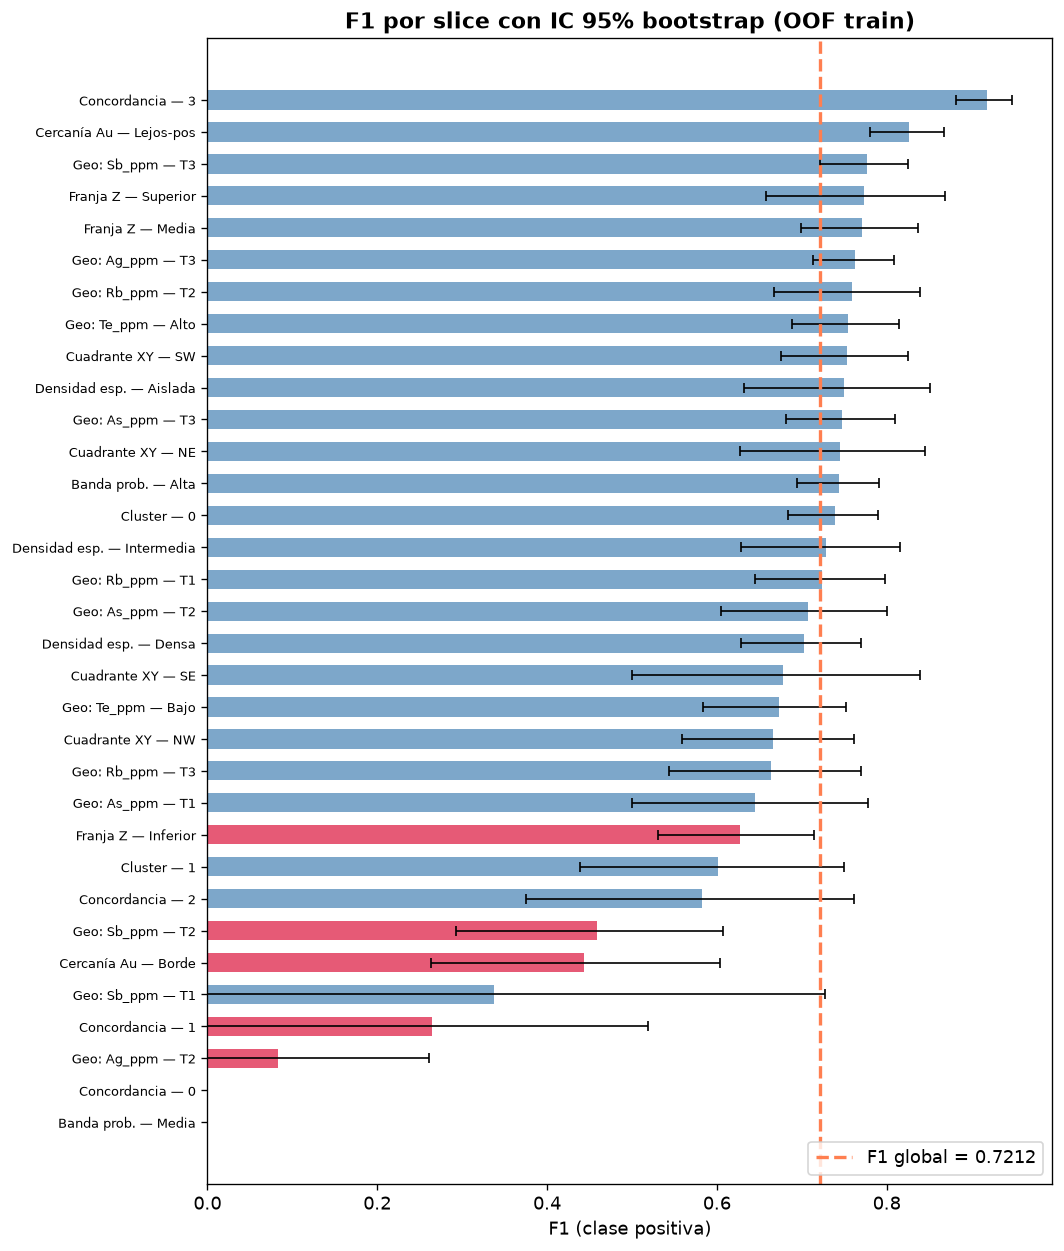

In [9]:
# ── Forest plot: F1 por slice con IC95% ──
plot_df = slices_df[slices_df['elegible']].copy()
plot_df = plot_df.sort_values('f1', ascending=True).reset_index(drop=True)
plot_df['label'] = plot_df['slice'] + ' — ' + plot_df['categoria'].astype(str)

fig, ax = plt.subplots(figsize=(9, max(5, len(plot_df) * 0.32)))
colors = ['crimson' if row['f1_hi'] < F1_BASE else 'steelblue' for _, row in plot_df.iterrows()]
ax.barh(range(len(plot_df)), plot_df['f1'], color=colors, alpha=0.7, height=0.6)
ax.errorbar(plot_df['f1'], range(len(plot_df)),
            xerr=[plot_df['f1'] - plot_df['f1_lo'], plot_df['f1_hi'] - plot_df['f1']],
            fmt='none', ecolor='black', capsize=3, lw=1)
ax.axvline(F1_BASE, ls='--', color='coral', lw=2, label=f'F1 global = {F1_BASE:.4f}')
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['label'], fontsize=8)
ax.set_xlabel('F1 (clase positiva)')
ax.set_title('F1 por slice con IC 95% bootstrap (OOF train)', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/forest_plot_slices.png', bbox_inches='tight')
plt.show()

## Fase A - Estrategia de mitigación candidatas

En la **Fase A** se evalúan tres estrategias de mitigación de forma **independiente**, todas contra el mismo baseline (campeón S3, OOF) y con el mismo criterio de aceptación:

| Estrategia | Descripción |
|---|---|
| **A1 — Stacking** | Meta-modelo de regresión logística entrenado sobre las probabilidades OOF de los tres modelos del top-3. Como las OOF se generaron cuando cada muestra estaba en el fold de validación, no hay fuga. Se evalúa con CV anidado (OOF del meta-modelo). |
| **A2 — Re-inclusión de features** | Se prueba si ampliar el set de features del campeón (re-incluyendo features descartadas en la selección, en orden de importancia SHAP) mejora el rendimiento. Grid de tamaños k entre el set seleccionado y el set completo. |
| **A3 — Umbral por slice** | Umbral de decisión diferenciado por categoría de un slice estructural (cuadrante XY, franja Z, banda de probabilidad), en lugar de un umbral global único. |

**Criterio de aceptación** (idéntico para las tres): la mejora ΔF1 sobre el baseline debe ser positiva y estadísticamente significativa según un **bootstrap pareado** (2000 réplicas): se acepta si p_boot < 0.05, donde p_boot es la proporción de réplicas con Δ ≤ 0.

Este criterio protege contra adoptar estrategias cuya ganancia aparente en OOF sea producto del azar o del sobreajuste de la política de decisión.

### A1 - Stacking (meta-modelo LogReg sobre OOF del top-3)

In [10]:
# ── A1: Stacking con CV anidado ──
t0 = time.time()

scaler_meta = StandardScaler()
X_meta = scaler_meta.fit_transform(OOF_MATRIX.values)

# OOF del meta-modelo (CV anidado)
oof_stack = np.zeros(len(y_train))
for tr_idx, va_idx in CV5.split(X_meta, y_train):
    lr = LogisticRegression(random_state=SEED, max_iter=1000, C=1.0)
    lr.fit(X_meta[tr_idx], y_train.iloc[tr_idx])
    oof_stack[va_idx] = lr.predict_proba(X_meta[va_idx])[:, 1]

umbral_A1 = umbral_optimo(y_train, oof_stack)
y_pred_A1 = (oof_stack >= umbral_A1).astype(int)
f1_A1 = f1_score(y_train, y_pred_A1)

# Referencia adicional: promedio simple de las 3 OOF
oof_avg = OOF_MATRIX.values.mean(axis=1)
umb_avg = umbral_optimo(y_train, oof_avg)
f1_avg = f1_score(y_train, (oof_avg >= umb_avg).astype(int))

# Meta-modelo final (todo el train) y coeficientes
meta_model = LogisticRegression(random_state=SEED, max_iter=1000, C=1.0)
meta_model.fit(X_meta, y_train)
coefs = {m: round(float(c), 4) for m, c in zip(TOP_3, meta_model.coef_[0])}

# Validación bootstrap pareada vs baseline
dA1, loA1, hiA1, pA1 = bootstrap_delta(y_train, y_pred_base, y_pred_A1)

elapsed = time.time() - t0
print(coral(f'A1 Stacking: F1_OOF = {f1_A1:.4f} (umbral = {umbral_A1:.4f}) [{elapsed:.1f}s]'))
print(f'   Promedio simple (referencia): F1_OOF = {f1_avg:.4f}')
print(f'   Coeficientes LogReg: {coefs}')
print(f'   ΔF1 vs baseline = {dA1:+.4f}  IC95% [{loA1:+.4f}, {hiA1:+.4f}]  p_boot = {pA1:.4f}')

A1 Stacking: F1_OOF = 0.7194 (umbral = 0.3572) [7.7s]
   Promedio simple (referencia): F1_OOF = 0.7249
   Coeficientes LogReg: {'CatBoost': 0.7645, 'XGBoost': 0.132, 'HistGradientBoosting': 0.9927}
   ΔF1 vs baseline = -0.0016  IC95% [-0.0278, +0.0252]  p_boot = 0.5560


### A2 - Re-inclusión de features

In [11]:
# ── A2: re-inclusión de features del campeón (grid de tamaños k) ──
t0 = time.time()
cfg_c = TOP3_CONFIG[CAMPEON_S3]
set_c = cfg_c['set']
Xtr_c_full = SETS_TR[set_c]

# Ranking SHAP completo del campeón (universo de re-inclusión)
ranking_shap = [f for f in shap_imp['feature'].tolist() if f in Xtr_c_full.columns]
n_sel = len(FEATURES_S3[CAMPEON_S3])
n_full = len(ranking_shap)

# Grid: desde el set seleccionado hasta el set completo
K_GRID = sorted(set([n_sel] + [k for k in [n_sel + 3, n_sel + 6, n_sel + 10, n_full] if n_sel < k <= n_full]))
print(f'Campeón: {CAMPEON_S3} | set seleccionado = {n_sel} features | universo = {n_full}')
print(f'Grid de k: {K_GRID}\n')

res_A2 = []
oof_A2_dict = {}
for k in K_GRID:
    feats_k = ranking_shap[:k]
    oof_k = oof_proba(lambda: make_pipe(CAMPEON_S3, PARAMS_CAMPEON, cfg_c['balanceo']),
                      Xtr_c_full[feats_k], y_train)
    umb_k = umbral_optimo(y_train, oof_k)
    f1_k = f1_score(y_train, (oof_k >= umb_k).astype(int))
    oof_A2_dict[k] = (oof_k, umb_k)
    res_A2.append({'k': k, 'f1_oof': f1_k, 'umbral': umb_k})
    print(f'  k = {k:3d} → F1_OOF = {f1_k:.4f} (umbral = {umb_k:.4f})')

df_A2 = pd.DataFrame(res_A2)
df_A2.to_csv(f'{DIR_TAB}/a2_reinclusion.csv', index=False)

# Mejor k del grid
k_A2 = int(df_A2.loc[df_A2['f1_oof'].idxmax(), 'k'])
oof_A2, umbral_A2 = oof_A2_dict[k_A2]
y_pred_A2 = (oof_A2 >= umbral_A2).astype(int)
f1_A2 = f1_score(y_train, y_pred_A2)

# Validación bootstrap pareada vs baseline
dA2, loA2, hiA2, pA2 = bootstrap_delta(y_train, y_pred_base, y_pred_A2)

elapsed = time.time() - t0
print(coral(f'\nA2 Re-inclusión: mejor k = {k_A2} → F1_OOF = {f1_A2:.4f} [{elapsed:.0f}s]'))
print(f'   ΔF1 vs baseline = {dA2:+.4f}  IC95% [{loA2:+.4f}, {hiA2:+.4f}]  p_boot = {pA2:.4f}')

Campeón: XGBoost | set seleccionado = 32 features | universo = 46
Grid de k: [32, 35, 38, 42, 46]

  k =  32 → F1_OOF = 0.7576 (umbral = 0.5013)
  k =  35 → F1_OOF = 0.7387 (umbral = 0.5200)
  k =  38 → F1_OOF = 0.7468 (umbral = 0.5357)
  k =  42 → F1_OOF = 0.7374 (umbral = 0.5103)
  k =  46 → F1_OOF = 0.7420 (umbral = 0.4709)

A2 Re-inclusión: mejor k = 32 → F1_OOF = 0.7576 [20s]
   ΔF1 vs baseline = +0.0364  IC95% [+0.0080, +0.0638]  p_boot = 0.0025


### A3 - Umbral diferenciado por slice

In [ ]:
# ── A3: umbral por slice (candidatos: cuadrante XY, franja Z, banda de probabilidad) ──
def umbral_por_slice(slice_cats, p_oof, y_true, umbral_global):
    """Optimiza umbral por categoría (mínimo 20 muestras y 5 positivos).
    Devuelve (predicciones, dict de umbrales)."""
    umbrales = {}
    y_pred = (p_oof >= umbral_global).astype(int)
    for cat in slice_cats.dropna().unique():
        mask = (slice_cats == cat).values
        if mask.sum() < 20 or y_true[mask].sum() < MIN_POS:
            umbrales[str(cat)] = float(umbral_global)
            continue
        best_thr = umbral_global
        best_f1 = f1_score(y_true[mask], y_pred[mask], zero_division=0)
        for thr in np.arange(0.10, 0.90, 0.01):
            f1_loc = f1_score(y_true[mask], (p_oof[mask] >= thr).astype(int), zero_division=0)
            if f1_loc > best_f1:
                best_f1, best_thr = f1_loc, thr
        umbrales[str(cat)] = float(best_thr)
        y_pred[mask] = (p_oof[mask] >= best_thr).astype(int)
    return y_pred, umbrales

CANDIDATOS_A3 = {
    'Cuadrante XY': pd.Series(slice_cuadrante),
    'Franja Z': pd.Series(slice_z),
    'Banda prob.': pd.Series(banda_prob),
}

res_A3 = []
preds_A3 = {}
for nombre, cats in CANDIDATOS_A3.items():
    y_p, umbs = umbral_por_slice(cats, p_oof_base, y_train, UMBRAL_S3)
    f1_s = f1_score(y_train, y_p)
    d, lo, hi, p = bootstrap_delta(y_train, y_pred_base, y_p)
    preds_A3[nombre] = (y_p, umbs)
    res_A3.append({'slice': nombre, 'f1_oof': f1_s, 'delta': d,
                   'ci_lo': lo, 'ci_hi': hi, 'p_boot': p})
    print(f'{nombre:15s}: F1_OOF = {f1_s:.4f} | Δ = {d:+.4f} '
          f'IC95% [{lo:+.4f}, {hi:+.4f}] p_boot = {p:.4f}')
    print(f'{"":15s}  umbrales: { {k: round(v, 3) for k, v in umbs.items()} }')

df_A3 = pd.DataFrame(res_A3)
df_A3.to_csv(f'{DIR_TAB}/a3_umbral_slice.csv', index=False)

# Mejor candidato A3 (por delta)
mejor_A3 = df_A3.loc[df_A3['delta'].idxmax()]
SLICE_A3 = mejor_A3['slice']
y_pred_A3, UMBRALES_A3 = preds_A3[SLICE_A3]
f1_A3 = float(mejor_A3['f1_oof'])
dA3, loA3, hiA3, pA3 = (float(mejor_A3['delta']), float(mejor_A3['ci_lo']),
                        float(mejor_A3['ci_hi']), float(mejor_A3['p_boot']))
print(coral(f'\nA3 mejor candidato: {SLICE_A3} → F1_OOF = {f1_A3:.4f} (p_boot = {pA3:.4f})'))

Cuadrante XY   : F1_OOF = 0.7430 | Δ = +0.0215 IC95% [-0.0070, +0.0520] p_boot = 0.0820
                 umbrales: {'NE': 0.421, 'SE': 0.5, 'SW': 0.25, 'NW': 0.26}
Franja Z       : F1_OOF = 0.7302 | Δ = +0.0085 IC95% [-0.0227, +0.0419] p_boot = 0.3045
                 umbrales: {'Inferior': 0.26, 'Superior': 0.5, 'Media': 0.24}
Banda prob.    : F1_OOF = 0.7212 | Δ = +0.0000 IC95% [+0.0000, +0.0000] p_boot = 1.0000
                 umbrales: {'Alta': 0.421, 'Baja': 0.421, 'Media': 0.421}

A3 mejor candidato: Cuadrante XY → F1_OOF = 0.7430 (p_boot = 0.0820)


## Resultados de la Fase A

Fase A — baseline F1_OOF = 0.7212


,estrategia,detalle,f1_oof,delta,ci_lo,ci_hi,p_boot,aceptada
0,A2_reinclusion,k = 32 features,0.757576,0.036376,0.008026,0.063802,0.0025,True
1,A3_umbral_slice,slice = Cuadrante XY,0.742991,0.021484,-0.006980,0.051975,0.0820,False
2,A1_stacking,LogReg sobre OOF top-3,0.719388,-0.001592,-0.027780,0.025247,0.5560,False



Estrategias aceptadas (Δ > 0 y p_boot < 0.05): ['A2_reinclusion']


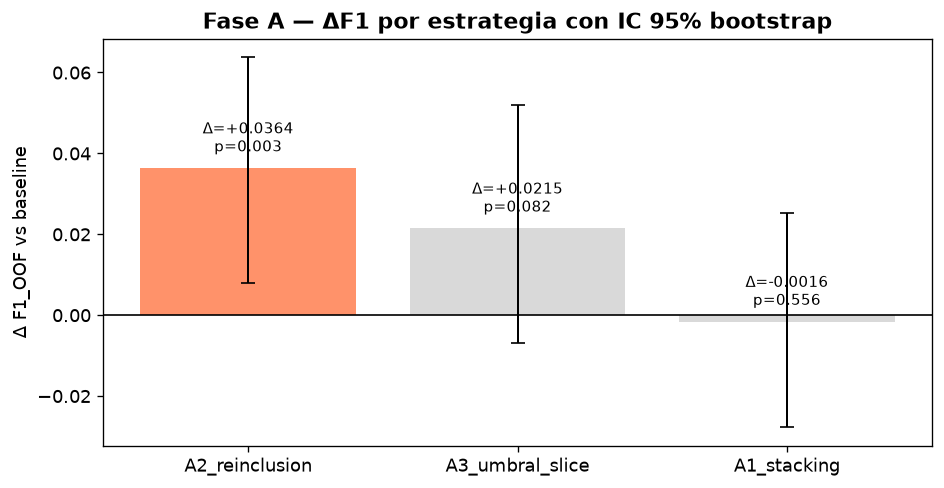

In [13]:
# ── Tabla Fase A: las 3 estrategias con el mismo criterio ──
fase_a = pd.DataFrame([
    {'estrategia': 'A1_stacking', 'detalle': f'LogReg sobre OOF top-3',
     'f1_oof': f1_A1, 'delta': dA1, 'ci_lo': loA1, 'ci_hi': hiA1, 'p_boot': pA1},
    {'estrategia': 'A2_reinclusion', 'detalle': f'k = {k_A2} features',
     'f1_oof': f1_A2, 'delta': dA2, 'ci_lo': loA2, 'ci_hi': hiA2, 'p_boot': pA2},
    {'estrategia': 'A3_umbral_slice', 'detalle': f'slice = {SLICE_A3}',
     'f1_oof': f1_A3, 'delta': dA3, 'ci_lo': loA3, 'ci_hi': hiA3, 'p_boot': pA3},
])
fase_a['aceptada'] = (fase_a['delta'] > 0) & (fase_a['p_boot'] < 0.05)
fase_a = fase_a.sort_values('delta', ascending=False).reset_index(drop=True)
fase_a.to_csv(f'{DIR_TAB}/fase_a_resultados.csv', index=False)

print(coral(f'Fase A — baseline F1_OOF = {F1_BASE:.4f}'))
display(fase_a)

aceptadas = fase_a[fase_a['aceptada']]['estrategia'].tolist()
print(f'\nEstrategias aceptadas (Δ > 0 y p_boot < 0.05): {aceptadas if aceptadas else "ninguna"}')

# Gráfico de deltas
fig, ax = plt.subplots(figsize=(8, 4.2))
colores_bar = ['coral' if a else 'lightgray' for a in fase_a['aceptada']]
ax.bar(fase_a['estrategia'], fase_a['delta'], color=colores_bar, alpha=0.85)
ax.errorbar(fase_a['estrategia'], fase_a['delta'],
            yerr=[fase_a['delta'] - fase_a['ci_lo'], fase_a['ci_hi'] - fase_a['delta']],
            fmt='none', ecolor='black', capsize=4, lw=1.2)
ax.axhline(0, color='black', lw=1)
for i, row in fase_a.iterrows():
    ax.annotate(f"Δ={row['delta']:+.4f}\np={row['p_boot']:.3f}", (i, row['delta']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax.set_ylabel('Δ F1_OOF vs baseline')
ax.set_title('Fase A — ΔF1 por estrategia con IC 95% bootstrap', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/fase_a_deltas.png', bbox_inches='tight')
plt.show()

## Fase B - Combinación forward incremental

En la **Fase B** las estrategias aceptadas en la Fase A se combinan de forma **forward incremental**:

1. Se ordenan las estrategias aceptadas por su ΔF1 (descendente).
2. Se parte de la mejor y se añade la siguiente **una a la vez**.
3. Cada adición se conserva únicamente si la combinación mejora significativamente a la combinación anterior (mismo bootstrap pareado, p_boot < 0.05).

Reglas de composición: A2 redefine el set de features del campeón (y su columna en el stacking); A1 combina las probabilidades de los tres modelos; A3 aplica umbrales por slice a la probabilidad final. Si ninguna estrategia fue aceptada en la Fase A, el modelo final del Sprint 4 es el baseline (campeón S3).

In [14]:
# ── Fase B: forward incremental ──
def construir_pred(combo, con_A2_oof=None):
    """Construye la predicción OOF para una combinación de estrategias.
    Devuelve (y_pred, p_final, umbral_o_dict)."""
    # Probabilidad base: OOF del campeón (con A2 si aplica)
    if 'A2_reinclusion' in combo and con_A2_oof is not None:
        p_campeon = con_A2_oof
    else:
        p_campeon = p_oof_base

    # A1: stacking (reemplaza la columna del campeón si A2 está activa)
    if 'A1_stacking' in combo:
        M = OOF_MATRIX.copy()
        M[CAMPEON_S3] = p_campeon
        sc_m = StandardScaler()
        Xm = sc_m.fit_transform(M.values)
        p_fin = np.zeros(len(y_train))
        for tr_idx, va_idx in CV5.split(Xm, y_train):
            lr = LogisticRegression(random_state=SEED, max_iter=1000, C=1.0)
            lr.fit(Xm[tr_idx], y_train.iloc[tr_idx])
            p_fin[va_idx] = lr.predict_proba(Xm[va_idx])[:, 1]
    else:
        p_fin = p_campeon

    # Umbral: global o por slice (A3)
    if 'A3_umbral_slice' in combo:
        umb_g = umbral_optimo(y_train, p_fin)
        y_p, umbs = umbral_por_slice(CANDIDATOS_A3[SLICE_A3], p_fin, y_train, umb_g)
        return y_p, p_fin, umbs
    else:
        umb_g = umbral_optimo(y_train, p_fin)
        return (p_fin >= umb_g).astype(int), p_fin, umb_g

# Orden forward (aceptadas, por delta desc)
orden_fw = fase_a[fase_a['aceptada']].sort_values('delta', ascending=False)['estrategia'].tolist()
print(f'Orden forward: {orden_fw if orden_fw else "— (ninguna aceptada)"}\n')

historial_fb = []
if not orden_fw:
    COMBO_FINAL = []
    y_pred_combo = y_pred_base
    p_oof_combo = p_oof_base
    umbral_combo = UMBRAL_S3
    F1_COMBO = F1_BASE
    print(coral('Ninguna estrategia aceptada → el modelo final del S4 es el baseline (campeón S3).'))
else:
    oof_A2_arr = oof_A2 if 'A2_reinclusion' in orden_fw else None
    # Paso 1: mejor estrategia sola
    COMBO_FINAL = [orden_fw[0]]
    y_pred_combo, p_oof_combo, umbral_combo = construir_pred(COMBO_FINAL, oof_A2_arr)
    F1_COMBO = f1_score(y_train, y_pred_combo)
    historial_fb.append({'combo': ' + '.join(COMBO_FINAL), 'f1_oof': F1_COMBO,
                         'delta_vs_ant': F1_COMBO - F1_BASE, 'p_boot': fase_a.iloc[0]['p_boot'],
                         'adoptada': True})
    print(f'Combo inicial: {COMBO_FINAL} → F1_OOF = {F1_COMBO:.4f}')

    # Pasos siguientes
    for estrategia in orden_fw[1:]:
        combo_cand = COMBO_FINAL + [estrategia]
        y_cand, p_cand, umb_cand = construir_pred(combo_cand, oof_A2_arr)
        f1_cand = f1_score(y_train, y_cand)
        d, lo, hi, p = bootstrap_delta(y_train, y_pred_combo, y_cand)
        adopta = (d > 0) and (p < 0.05)
        historial_fb.append({'combo': ' + '.join(combo_cand), 'f1_oof': f1_cand,
                             'delta_vs_ant': d, 'p_boot': p, 'adoptada': adopta})
        print(f'+ {estrategia}: F1_OOF = {f1_cand:.4f} | Δ = {d:+.4f} p_boot = {p:.4f} '
              f'→ {"ADOPTADA" if adopta else "rechazada"}')
        if adopta:
            COMBO_FINAL = combo_cand
            y_pred_combo, p_oof_combo, umbral_combo = y_cand, p_cand, umb_cand
            F1_COMBO = f1_cand

df_fb = pd.DataFrame(historial_fb) if historial_fb else pd.DataFrame(
    [{'combo': 'baseline', 'f1_oof': F1_BASE, 'delta_vs_ant': 0.0, 'p_boot': np.nan, 'adoptada': True}])
df_fb.to_csv(f'{DIR_TAB}/fase_b_forward.csv', index=False)

print(coral(f'\nCombinación final: {COMBO_FINAL if COMBO_FINAL else "baseline (campeón S3)"}'))
print(coral(f'F1_OOF final: {F1_COMBO:.4f} (baseline: {F1_BASE:.4f}, Δ total = {F1_COMBO - F1_BASE:+.4f})'))

Orden forward: ['A2_reinclusion']

Combo inicial: ['A2_reinclusion'] → F1_OOF = 0.7576

Combinación final: ['A2_reinclusion']
F1_OOF final: 0.7576 (baseline: 0.7212, Δ total = +0.0363)


## Evaluación en hold-out

Se materializa la combinación final sobre **todo el conjunto de entrenamiento** y se aplica **una sola vez** al hold-out. Esta evaluación es terminal: no se realizan ajustes posteriores basados en sus resultados.

Reglas de materialización: si A2 está en la combinación, el campeón se re-entrena con su set ampliado (calibrado con el mismo método del Sprint 3); si A1 está, el meta-modelo se entrena sobre las OOF finales y se aplica sobre las probabilidades de test de los tres modelos; si A3 está, se aplican los umbrales por slice (con los bordes calculados en train).

In [15]:
# ── Probabilidades de test de los 3 modelos (modelos calibrados del S3) ──
p_test = {}
for m in TOP_3:
    feats = FEATURES_S3[m]
    s = TOP3_CONFIG[m]['set']
    p_test[m] = modelos_cal[m].predict_proba(SETS_TE[s][feats])[:, 1]
    print(f'{m}: {len(feats)} features → P(+) media test = {p_test[m].mean():.4f}')

# ── A2: re-entrenar campeón con set ampliado (si está en el combo) ──
if 'A2_reinclusion' in COMBO_FINAL:
    feats_final_campeon = ranking_shap[:k_A2]
    modelo_campeon_final = CalibratedClassifierCV(
        make_pipe(CAMPEON_S3, PARAMS_CAMPEON, TOP3_CONFIG[CAMPEON_S3]['balanceo']),
        method=CAL_CAMPEON, cv=5)
    modelo_campeon_final.fit(SETS_TR[TOP3_CONFIG[CAMPEON_S3]['set']][feats_final_campeon], y_train)
    p_test[CAMPEON_S3] = modelo_campeon_final.predict_proba(
        SETS_TE[TOP3_CONFIG[CAMPEON_S3]['set']][feats_final_campeon])[:, 1]
    print(f'\nA2 activa: campeón re-entrenado con {k_A2} features')
else:
    feats_final_campeon = FEATURES_S3[CAMPEON_S3]
    modelo_campeon_final = modelos_cal[CAMPEON_S3]

# ── A1: meta-modelo final (si está en el combo) ──
if 'A1_stacking' in COMBO_FINAL:
    M_final = OOF_MATRIX.copy()
    if 'A2_reinclusion' in COMBO_FINAL:
        M_final[CAMPEON_S3] = oof_A2
    scaler_final = StandardScaler()
    Xm_final = scaler_final.fit_transform(M_final.values)
    meta_final = LogisticRegression(random_state=SEED, max_iter=1000, C=1.0)
    meta_final.fit(Xm_final, y_train)
    Xm_test = scaler_final.transform(pd.DataFrame(p_test)[TOP_3].values)
    p_test_final = meta_final.predict_proba(Xm_test)[:, 1]
    print('A1 activa: predicción de test con stacking')
else:
    meta_final, scaler_final = None, None
    p_test_final = p_test[CAMPEON_S3]
    print('Predicción de test con el campeón individual')

# ── A3 / umbral: aplicar la política de decisión final ──
if 'A3_umbral_slice' in COMBO_FINAL:
    # Reconstruir el slice A3 en test con bordes de TRAIN
    if SLICE_A3 == 'Cuadrante XY':
        cats_te = coords_test.apply(cuadrante, axis=1, me=med_e, mn=med_n).astype('category')
    elif SLICE_A3 == 'Franja Z':
        cats_te = pd.cut(level_test, bins=cortes_z, labels=labels_z, include_lowest=True)
    else:  # Banda prob.
        cats_te = pd.cut(p_test_final, bins=[-np.inf, EDGES_PROB[0], EDGES_PROB[1], np.inf],
                         labels=['Baja', 'Media', 'Alta'])
    cats_te = pd.Series(cats_te)
    # umbral_combo es el dict de umbrales por categoría devuelto por construir_pred
    umbrales_final = umbral_combo if isinstance(umbral_combo, dict) else UMBRALES_A3
    umb_default = umbral_optimo(y_train, p_oof_combo)
    y_pred_ho = np.zeros(len(y_test), dtype=int)
    for i in range(len(y_test)):
        thr = umbrales_final.get(str(cats_te.iloc[i]), umb_default)
        y_pred_ho[i] = int(p_test_final[i] >= thr)
    print(f'A3 activa: umbrales por {SLICE_A3} aplicados en test')
else:
    UMBRAL_FINAL_GLOBAL = umbral_combo if not isinstance(umbral_combo, dict) else UMBRAL_S3
    y_pred_ho = (p_test_final >= UMBRAL_FINAL_GLOBAL).astype(int)
    print(f'Umbral global aplicado en test: {UMBRAL_FINAL_GLOBAL:.4f}')

CatBoost: 29 features → P(+) media test = 0.1289
XGBoost: 32 features → P(+) media test = 0.1352
HistGradientBoosting: 25 features → P(+) media test = 0.1339

A2 activa: campeón re-entrenado con 32 features
Predicción de test con el campeón individual
Umbral global aplicado en test: 0.5013


In [16]:
# ── Métricas completas del hold-out ──
metr_ho = {
    'F1': f1_score(y_test, y_pred_ho),
    'Accuracy': accuracy_score(y_test, y_pred_ho),
    'Precision': precision_score(y_test, y_pred_ho, zero_division=0),
    'Recall': recall_score(y_test, y_pred_ho, zero_division=0),
    'AUC-ROC': roc_auc_score(y_test, p_test_final),
    'AUC-PR': average_precision_score(y_test, p_test_final),
    'Brier': brier_score_loss(y_test, p_test_final),
}
F1_HOLDOUT = metr_ho['F1']
_, f1_ho_lo, f1_ho_hi = bootstrap_f1(y_test, y_pred_ho)

print(coral('══════ HOLD-OUT FINAL ══════'))
for k, v in metr_ho.items():
    print(f'  {k:12s}: {v:.4f}')
print(f'  F1 IC 95%  : [{f1_ho_lo:.4f}, {f1_ho_hi:.4f}]')

══════ HOLD-OUT FINAL ══════
  F1          : 0.7677
  Accuracy    : 0.9461
  Precision   : 0.8085
  Recall      : 0.7308
  AUC-ROC     : 0.9607
  AUC-PR      : 0.8370
  Brier       : 0.0427
  F1 IC 95%  : [0.6605, 0.8515]


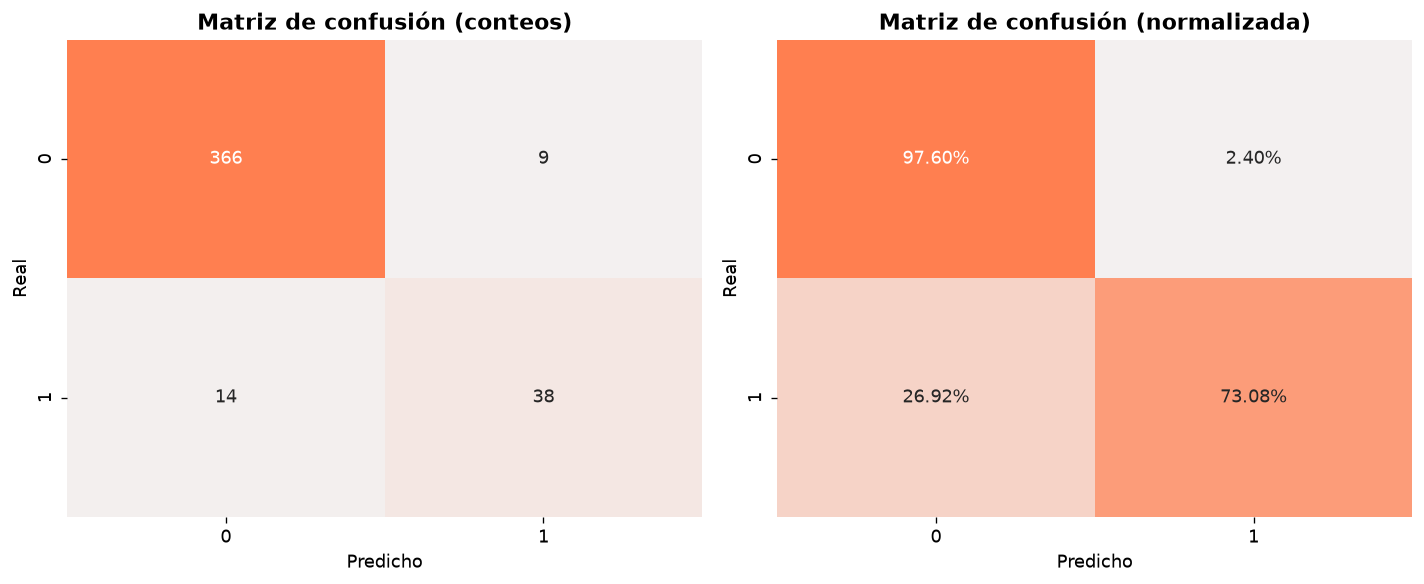

In [17]:
# ── Matrices de confusión ──
cm = confusion_matrix(y_test, y_pred_ho)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=axes[0],
            cmap=sns.light_palette('coral', as_cmap=True))
axes[0].set_title('Matriz de confusión (conteos)', fontweight='bold')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cbar=False, ax=axes[1],
            cmap=sns.light_palette('coral', as_cmap=True))
axes[1].set_title('Matriz de confusión (normalizada)', fontweight='bold')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/holdout_matrices_confusion.png', bbox_inches='tight')
plt.show()

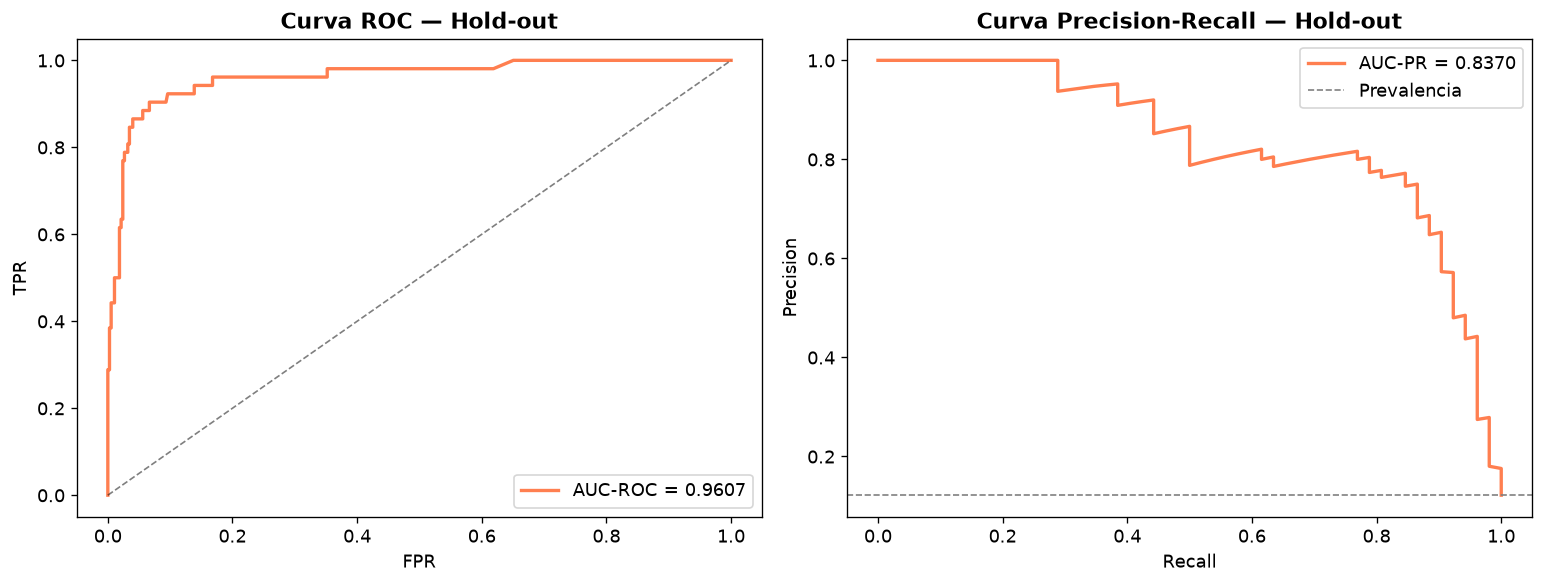

In [18]:
# ── Curvas ROC y PR ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fpr, tpr, _ = roc_curve(y_test, p_test_final)
axes[0].plot(fpr, tpr, color='coral', lw=2, label=f"AUC-ROC = {metr_ho['AUC-ROC']:.4f}")
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC — Hold-out', fontweight='bold'); axes[0].legend()

prec_ho, rec_ho, _ = precision_recall_curve(y_test, p_test_final)
axes[1].plot(rec_ho, prec_ho, color='coral', lw=2, label=f"AUC-PR = {metr_ho['AUC-PR']:.4f}")
axes[1].axhline(y_test.mean(), ls='--', color='gray', lw=1, label='Prevalencia')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — Hold-out', fontweight='bold'); axes[1].legend()
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/holdout_curvas_roc_pr.png', bbox_inches='tight')
plt.show()

In [19]:
# ── F1 por slice en hold-out (bordes de TRAIN) ──
banda_prob_te = pd.cut(p_test_final, bins=[-np.inf, EDGES_PROB[0], EDGES_PROB[1], np.inf],
                       labels=['Baja', 'Media', 'Alta'])
pred_ind_te = {}
for m in TOP_3:
    umb_m = RESUMEN_S3['top_3_pipeline'][m]['umbral']
    pred_ind_te[m] = (p_test[m] >= umb_m).astype(int)
concordancia_te = sum(pred_ind_te[m] for m in TOP_3)
slice_au_te = pd.cut(au_test - 0.10, bins=EDGES_AU, labels=['Lejos-neg', 'Borde', 'Lejos-pos'])
cuad_te = coords_test.apply(cuadrante, axis=1, me=med_e, mn=med_n).astype('category')
z_te = pd.cut(level_test, bins=cortes_z, labels=labels_z, include_lowest=True)
d_te, _ = tree_train.query(coords_test[['East', 'North']].values, k=10)
dens_te = pd.cut(d_te[:, 9], bins=cortes_d, labels=labels_d, include_lowest=True)
cluster_te = pd.Categorical(cl_te['kmeans_label_raw'].astype(str))

slices_test = [
    ('Banda prob.', pd.Series(banda_prob_te)),
    ('Concordancia', pd.Series(pd.Categorical(concordancia_te, categories=[0, 1, 2, 3]))),
    ('Cercanía Au', pd.Series(slice_au_te)),
    ('Cuadrante XY', pd.Series(cuad_te)),
    ('Franja Z', pd.Series(z_te)),
    ('Densidad esp.', pd.Series(dens_te)),
    ('Cluster', pd.Series(cluster_te)),
]

filas_te = []
for nombre, cats in slices_test:
    filas_te.extend(evaluar_slice(nombre, cats, y_test, y_pred_ho))
slices_test_df = pd.DataFrame(filas_te)
slices_test_df.to_csv(f'{DIR_TAB}/slices_f1_holdout.csv', index=False)

print(coral(f'F1 hold-out global: {F1_HOLDOUT:.4f}'))
print('\nF1 por slice en hold-out:')
display(slices_test_df[slices_test_df['elegible']].sort_values('f1'))

F1 hold-out global: 0.7677

F1 por slice en hold-out:


,slice,categoria,n,n_pos,f1,f1_lo,f1_hi,elegible
3,Concordancia,0,363,6,0.0000,0.0000,0.0000,True
18,Densidad esp.,Intermedia,118,13,0.3746,0.1051,0.6286,True
8,Cercanía Au,Borde,31,9,0.4365,0.1333,0.7000,True
4,Concordancia,1,13,6,0.4602,0.0000,0.8571,True
12,Cuadrante XY,SE,107,6,0.5106,0.1538,0.8000,True
16,Franja Z,Superior,152,12,0.5818,0.3333,0.7857,True
10,Cuadrante XY,NE,113,12,0.6879,0.4167,0.8889,True
14,Franja Z,Inferior,144,17,0.7066,0.4761,0.8750,True
21,Cluster,1,231,10,0.7306,0.4000,0.9474,True
19,Densidad esp.,Aislada,163,12,0.7614,0.5263,0.9231,True


## Persistencia de artefactos

In [20]:
# ── Guardar artefactos ──
pd.DataFrame(p_test).to_csv(f'{DIR_DATA}/probabilidades_test_top3.csv', index=False)
pd.DataFrame({'y_test': y_test.values, 'y_pred': y_pred_ho,
              'p_final': p_test_final}).to_csv(f'{DIR_DATA}/predicciones_holdout.csv', index=False)

# Modelos finales
joblib.dump(modelo_campeon_final, f'{DIR_MOD}/modelo_campeon_final.pkl')
if meta_final is not None:
    joblib.dump({'scaler': scaler_final, 'meta_model': meta_final, 'orden_modelos': TOP_3},
                f'{DIR_MOD}/meta_stacking_final.pkl')

# Config del modelo final
config_final = {
    'combo_final': COMBO_FINAL if COMBO_FINAL else ['baseline_campeon_s3'],
    'campeon_s3': CAMPEON_S3,
    'features_campeon': feats_final_campeon,
    'usa_stacking': 'A1_stacking' in COMBO_FINAL,
    'usa_reinclusion': 'A2_reinclusion' in COMBO_FINAL,
    'usa_umbral_slice': 'A3_umbral_slice' in COMBO_FINAL,
    'umbral': umbral_combo if not isinstance(umbral_combo, dict) else None,
    'umbrales_por_slice': umbral_combo if isinstance(umbral_combo, dict) else None,
    'slice_a3': SLICE_A3 if 'A3_umbral_slice' in COMBO_FINAL else None,
    'f1_oof': round(float(F1_COMBO), 4),
    'f1_holdout': round(float(F1_HOLDOUT), 4),
}
with open(f'{DIR_DATA}/config_final_s4.json', 'w') as f:
    json.dump(config_final, f, indent=2, ensure_ascii=False)

# Edges de slices (reproducibilidad)
edges_all = {'prob': EDGES_PROB, 'geo': EDGES_GEO, 'au': [e for e in EDGES_AU if np.isfinite(e)],
             'xy': EDGES_XY, 'z': EDGES_Z, 'densidad': EDGES_DENS}
with open(f'{DIR_DATA}/edges_slices.json', 'w') as f:
    json.dump(edges_all, f, indent=2, ensure_ascii=False)

print(f'Artefactos guardados en {OUT}/')
for d in [DIR_DATA, DIR_MOD, DIR_FIG, DIR_TAB]:
    print(f'  {d}: {len(os.listdir(d))} archivos')

Artefactos guardados en outputs_sprint4/
  outputs_sprint4/data: 4 archivos
  outputs_sprint4/models: 1 archivos
  outputs_sprint4/figures: 4 archivos
  outputs_sprint4/tables: 7 archivos


## Resumen

In [21]:
# ── Resumen JSON ──
resumen4 = {
    'sprint': 4,
    'nombre': 'Plan de mitigación: slices + Fase A (A1-A3) + Fase B (forward) + hold-out',
    'fecha': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'protocolo': ('Diagnóstico por slices (embudo 3 etapas); Fase A: A1 stacking, A2 re-inclusión, '
                  'A3 umbral por slice, aceptación por bootstrap pareado (p<0.05); Fase B: forward '
                  'incremental de aceptadas; hold-out una sola vez.'),
    'baseline': {'modelo': CAMPEON_S3, 'f1_oof': round(F1_BASE, 4), 'umbral': round(UMBRAL_S3, 4)},
    'combo_final': COMBO_FINAL if COMBO_FINAL else ['baseline_campeon_s3'],
    'f1_oof_final': round(float(F1_COMBO), 4),
    'f1_holdout': round(float(F1_HOLDOUT), 4),
    'f1_holdout_ci95': [round(f1_ho_lo, 4), round(f1_ho_hi, 4)],
    'metricas_holdout': {k: round(v, 4) for k, v in metr_ho.items()},
    'fase_a': fase_a.round(4).to_dict(orient='records'),
    'fase_b': df_fb.round(4).to_dict(orient='records'),
    'a1_stacking': {'f1_oof': round(f1_A1, 4), 'coeficientes': coefs,
                    'f1_promedio_simple': round(f1_avg, 4)},
    'a2_reinclusion': {'mejor_k': k_A2, 'n_seleccion_s3': n_sel, 'grid': K_GRID,
                       'f1_oof': round(f1_A2, 4)},
    'a3_umbral_slice': {'mejor_slice': SLICE_A3, 'f1_oof': round(f1_A3, 4),
                        'candidatos': df_A3.round(4).to_dict(orient='records')},
    'slices_embudo': {
        'n_elegibles': int(n_etapa1), 'n_etapa2_ic95': int(n_etapa2),
        'n_etapa3_bonferroni': int(n_etapa3),
        'problematicos': problematicos[['slice', 'categoria', 'f1']].to_dict(orient='records')
                         if len(problematicos) > 0 else [],
    },
    'evolucion_f1': {
        'S0': RESUMEN_S0['f1_final'], 'S1': RESUMEN_S1['f1_final'],
        'S2': RESUMEN_S2['f1_final'], 'S3': F1_SPRINT3,
        'S4': round(float(F1_COMBO), 4),
    },
    'versiones_librerias': versiones,
}
with open(f'{OUT}/resumen_sprint4.json', 'w') as f:
    json.dump(resumen4, f, indent=2, ensure_ascii=False)

print(coral('════════════════════ RESUMEN SPRINT 4 ════════════════════'))
print(f'Baseline (campeón S3): {CAMPEON_S3} — F1_OOF = {F1_BASE:.4f}')
print(f'\nFase A:')
for _, r in fase_a.iterrows():
    print(f'  {r["estrategia"]:18s}: F1_OOF = {r["f1_oof"]:.4f} | Δ = {r["delta"]:+.4f} | '
          f'p = {r["p_boot"]:.4f} | {"ACEPTADA" if r["aceptada"] else "rechazada"}')
print(f'\nFase B → combinación final: {COMBO_FINAL if COMBO_FINAL else "baseline"}')
print(f'F1_OOF final: {F1_COMBO:.4f} (Δ total vs baseline = {F1_COMBO - F1_BASE:+.4f})')
print(f'\nHold-out: F1 = {F1_HOLDOUT:.4f} [{f1_ho_lo:.4f}, {f1_ho_hi:.4f}]')
print(f'Slices problemáticos confirmados: {n_etapa3} de {n_etapa1}')
print(f'\nEvolución del proyecto (F1):')
evo = resumen4['evolucion_f1']
claves = list(evo.keys())
for i, s in enumerate(claves):
    delta = f' ({evo[s] - evo[claves[i-1]]:+.4f})' if i > 0 else ''
    print(f'   {s} = {evo[s]:.4f}{delta}')

════════════════════ RESUMEN SPRINT 4 ════════════════════
Baseline (campeón S3): XGBoost — F1_OOF = 0.7212

Fase A:
  A2_reinclusion    : F1_OOF = 0.7576 | Δ = +0.0364 | p = 0.0025 | ACEPTADA
  A3_umbral_slice   : F1_OOF = 0.7430 | Δ = +0.0215 | p = 0.0820 | rechazada
  A1_stacking       : F1_OOF = 0.7194 | Δ = -0.0016 | p = 0.5560 | rechazada

Fase B → combinación final: ['A2_reinclusion']
F1_OOF final: 0.7576 (Δ total vs baseline = +0.0363)

Hold-out: F1 = 0.7677 [0.6605, 0.8515]
Slices problemáticos confirmados: 6 de 33

Evolución del proyecto (F1):
   S0 = 0.7090
   S1 = 0.7277 (+0.0187)
   S2 = 0.7493 (+0.0216)
   S3 = 0.7598 (+0.0105)
   S4 = 0.7576 (-0.0022)


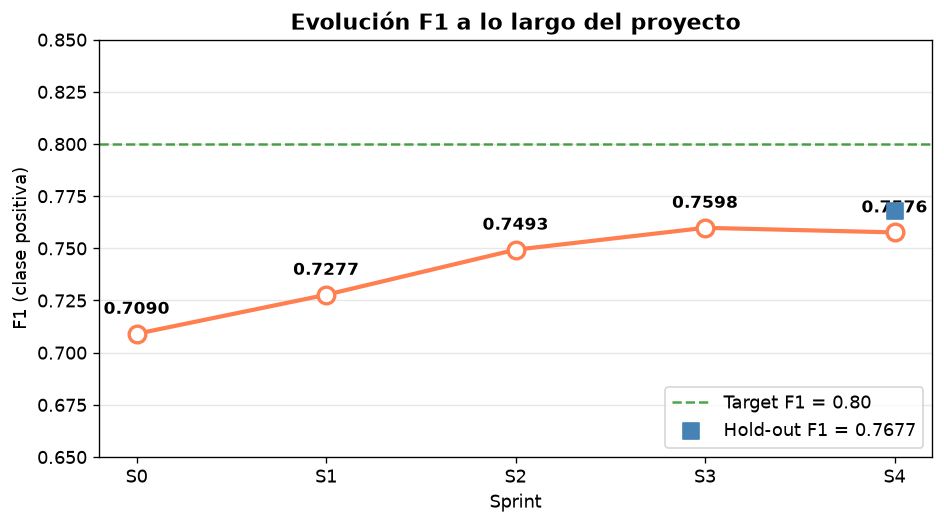

In [22]:
# ── Gráfico de evolución del proyecto ──
evo = resumen4['evolucion_f1']
sprints = list(evo.keys())
f1_vals = list(evo.values())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sprints, f1_vals, marker='o', markersize=10, lw=2.5, color='coral',
        markerfacecolor='white', markeredgecolor='coral', markeredgewidth=2)
for i, (s, v) in enumerate(zip(sprints, f1_vals)):
    ax.annotate(f'{v:.4f}', (i, v), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=10, fontweight='bold')
ax.axhline(0.80, ls='--', color='green', lw=1.5, alpha=0.7, label='Target F1 = 0.80')
ax.scatter([sprints[-1]], [F1_HOLDOUT], marker='s', s=100, color='steelblue',
           zorder=5, label=f'Hold-out F1 = {F1_HOLDOUT:.4f}')
ax.set_xlabel('Sprint'); ax.set_ylabel('F1 (clase positiva)')
ax.set_title('Evolución F1 a lo largo del proyecto', fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0.65, max(max(f1_vals), F1_HOLDOUT, 0.80) + 0.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DIR_FIG}/evolucion_f1_proyecto.png', bbox_inches='tight')
plt.show()